In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import os
import re

import sklearn
import sklearn.model_selection
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf

# Use keras 2
import tf_keras as tfk
os.environ["TF_USE_LEGACY_KERAS"] ="1"

## Use keras 3
#tfk = tf.keras

from normalizing_flow import MAF

2025-11-04 09:47:45.127524: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-04 09:47:45.127599: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-04 09:47:45.127621: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-04 09:47:45.134864: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
flist = np.loadtxt('data/QCD_NF8/flist', dtype=str)
flist_tokens = []
for f in flist:
    f=f.replace('_bis', '')
    f=f.replace('_ter', '')
    f=f.replace('Nt8_', '8 ')
    f=f.replace('NF8_', '')
    f=f.replace('ferm_Ns', '')
    f=f.replace('b', '')
    f=f.replace('M0p', '0.')
    f=f.replace('_', ' ')
    tokens = f.split()
    tokens = [tokens[3], tokens[2], tokens[0], tokens[1]]
    flist_tokens = flist_tokens + [tokens]

In [4]:
def extract_vars(l):
    beta = float(l[0])
    m = float(l[1])
    ns = float(l[2])
    nt = float(l[3])
    return beta, m, ns, nt

In [5]:
flist[0]

'ferm_Ns12_Nt8_NF8_M0p0085_b2.2550'

In [6]:
flist_tokens[0]

['2.2550', '0.0085', '12', '8']

In [7]:
extract_vars(flist_tokens[0])

(2.255, 0.0085, 12.0, 8.0)

In [8]:
therm = 400
each = 1

plaq = np.loadtxt('data/QCD_NF8/'+flist[0])[therm::each,2]
ff = np.loadtxt('data/QCD_NF8/'+flist[0])[therm::each,4]
(beta, m, ns, nt) = extract_vars(flist_tokens[0])
M = plaq
M = np.vstack([M, ff])
M = np.vstack([M, beta*np.ones(plaq.size)])
M = np.vstack([M, m*np.ones(plaq.size)])
M = np.vstack([M, ns*np.ones(plaq.size)])

for i in np.arange(1,flist.size):
    plaq = np.loadtxt('data/QCD_NF8/'+flist[i])[therm::each,2]
    ff = np.loadtxt('data/QCD_NF8/'+flist[i])[therm::each,4]
    (beta, m, ns, nt) = extract_vars(flist_tokens[i])
    N = plaq
    N = np.vstack([N, ff])
    N = np.vstack([N, beta*np.ones(plaq.size)])
    N = np.vstack([N, m*np.ones(plaq.size)])
    N = np.vstack([N, ns*np.ones(plaq.size)])
    M = np.hstack([M, N])
M = M.transpose()

In [9]:
M.shape

(2507411, 5)

In [10]:
M[0:3]

array([[3.00146807e-01, 1.00105486e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01],
       [3.00146807e-01, 1.16423067e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01],
       [3.00146807e-01, 1.05576065e+00, 2.25500000e+00, 8.50000000e-03,
        1.20000000e+01]])

In [11]:
np.argwhere(np.isnan(M))

array([], shape=(0, 2), dtype=int64)

In [12]:
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(M, np.ones(M.shape[0]))

In [13]:
scaler=MinMaxScaler()
scaler.fit_transform(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [14]:
nvars = 2 # plaq, ff
ncondvars = 3 # beta, m, ns (NO nt)

nflow = MAF(nvars, ncondvars, nblocks=12, hidden_units=[64, 64], activation='relu', last_activation='relu', l1=0.0, l2=1.0e-4)

nflow.load_weights('my_qcdnf8_model.weights')

#print(nflow.trainable_variables)

#nflow.compile(optimizer=tfk.optimizers.Adam(learning_rate=1.0e-3), loss=lambda _, log_prob: -log_prob)

2025-11-04 09:48:12.931858: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37644 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:25:00.0, compute capability: 8.0


In [15]:
def calc_obs(beta, m, ns, nsamples=10000):

    cond = scaler.transform(np.array([[0.0, 0.0, beta, m, ns]]))[0][2:]
    samples = nflow.sample(cond, nsamples)
    h = np.vstack([samples[:,0], samples[:,1]])
    h = np.vstack([h, np.zeros((3,nsamples))])
    h = h.transpose()
    myplaq = scaler.inverse_transform(h)[:,0]
    myff = scaler.inverse_transform(h)[:,1]
    
    return (np.mean(myplaq), np.std(myplaq)/np.sqrt(nsamples), np.mean(myff), np.std(myff)/np.sqrt(nsamples))

Text(0, 0.5, 'Plaquette')

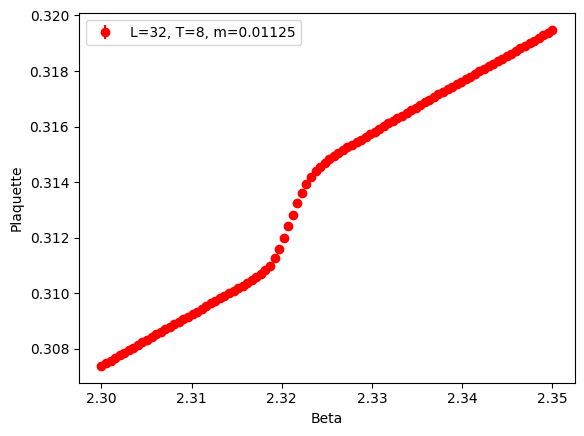

In [16]:
# mass = 0.01125 not in training data

mybeta = np.linspace(2.300, 2.350, 100)

mym = 0.01125
myns = 32

myplaq32 = np.array([])
dmyplaq32 = np.array([])
myff32 = np.array([])
dmyff32 = np.array([])

for x in mybeta:
    (a,b,c,d) = calc_obs(x, mym, myns, nsamples=10000)
    myplaq32 = np.append(myplaq32, a)
    dmyplaq32 = np.append(dmyplaq32, b)
    myff32 = np.append(myff32, c)
    dmyff32 = np.append(dmyff32, d)

plt.errorbar(mybeta, myplaq32, dmyplaq32, linestyle='', marker='o', color='red', label=f'L=32, T=8, m={mym}')
plt.legend()
plt.xlabel('Beta')
plt.ylabel('Plaquette')

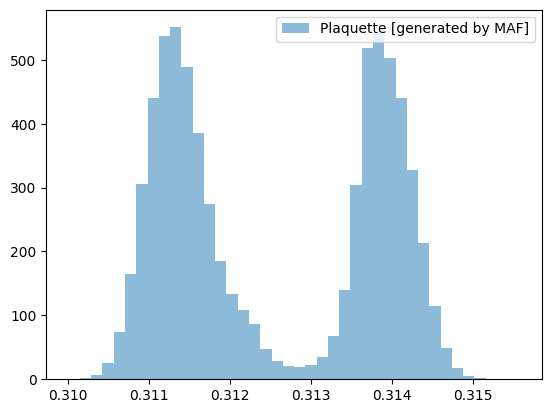

In [17]:
# mass = 0.01125 not in training data

nsamples = 500000

cond = scaler.transform(np.array([[0.0, 0.0, 2.3209, 0.01125, 32]]))[0][2:]
samples = nflow.sample(cond, nsamples)
h = np.vstack([samples[:,0], samples[:,1]])
h = np.vstack([h, np.zeros((3,nsamples))])
h = h.transpose()
unscaled_samples = scaler.inverse_transform(h)[:,0]
plt.hist(unscaled_samples, 40, alpha=0.5, density=True, label='Plaquette [generated by MAF]');

plt.legend()

Text(0, 0.5, 'Chiral condensate')

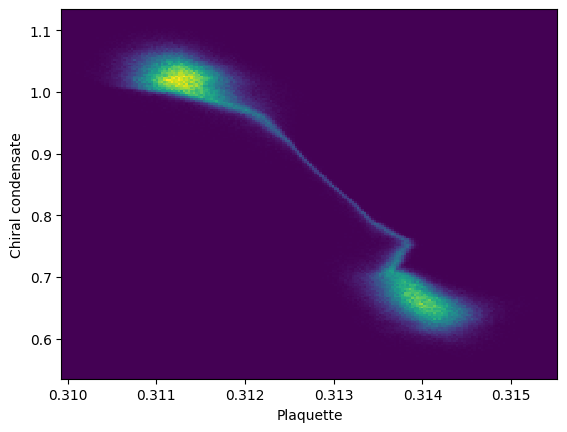

In [18]:
# mass = 0.01125 not in training data

nsamples = 500000

cond = scaler.transform(np.array([[0.0, 0.0, 2.3209, 0.01125, 32]]))[0][2:]
samples = nflow.sample(cond, nsamples)
h = np.vstack([samples[:,0], samples[:,1]])
h = np.vstack([h, np.zeros((3,nsamples))])
h = h.transpose()
unscaled_samples_PL = scaler.inverse_transform(h)[:,0]
unscaled_samples_FF = scaler.inverse_transform(h)[:,1]
plt.hist2d(unscaled_samples_PL, unscaled_samples_FF, bins=200);

plt.xlabel('Plaquette')
plt.ylabel('Chiral condensate')

Text(0, 0.5, 'Plaquette')

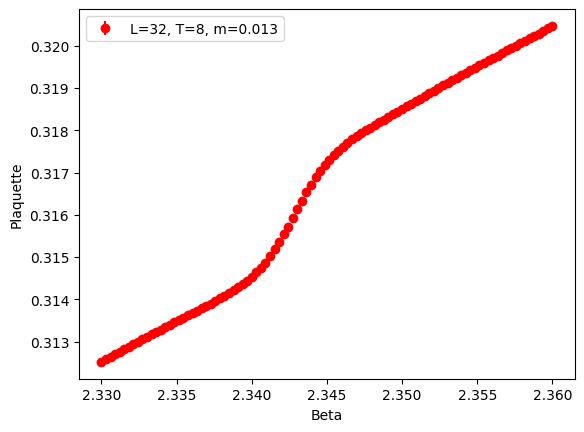

In [19]:
# mass = 0.01300 not in training data either

mybeta = np.linspace(2.330, 2.360, 100)

mym = 0.01300
myns = 32

myplaq32 = np.array([])
dmyplaq32 = np.array([])
myff32 = np.array([])
dmyff32 = np.array([])

for x in mybeta:
    (a,b,c,d) = calc_obs(x, mym, myns, nsamples=10000)
    myplaq32 = np.append(myplaq32, a)
    dmyplaq32 = np.append(dmyplaq32, b)
    myff32 = np.append(myff32, c)
    dmyff32 = np.append(dmyff32, d)

plt.errorbar(mybeta, myplaq32, dmyplaq32, linestyle='', marker='o', color='red', label=f'L=32, T=8, m={mym}')
plt.legend()
plt.xlabel('Beta')
plt.ylabel('Plaquette')

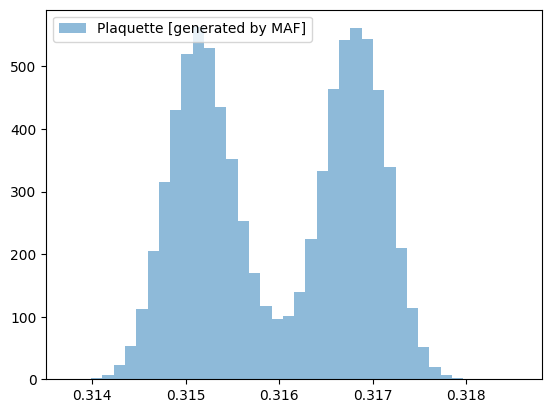

In [20]:
# mass = 0.01300 not in training data either

nsamples = 500000

cond = scaler.transform(np.array([[0.0, 0.0, 2.3428, 0.01300, 32]]))[0][2:]
samples = nflow.sample(cond, nsamples)
h = np.vstack([samples[:,0], samples[:,1]])
h = np.vstack([h, np.zeros((3,nsamples))])
h = h.transpose()
unscaled_samples = scaler.inverse_transform(h)[:,0]
plt.hist(unscaled_samples, 40, alpha=0.5, density=True, label='Plaquette [generated by MAF]');

plt.legend()

Text(0, 0.5, 'Chiral condensate')

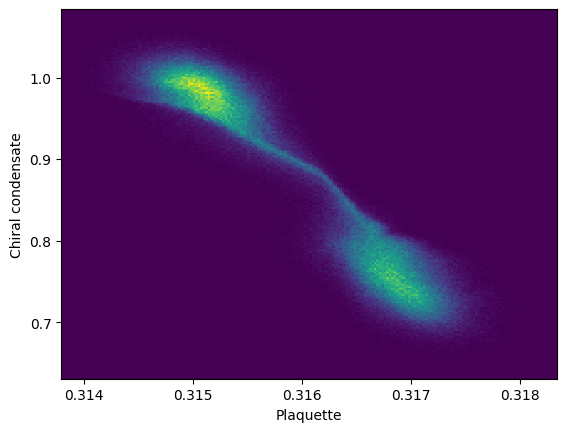

In [21]:
# mass = 0.01300 not in training data either

nsamples = 500000

cond = scaler.transform(np.array([[0.0, 0.0, 2.3428, 0.01300, 32]]))[0][2:]
samples = nflow.sample(cond, nsamples)
h = np.vstack([samples[:,0], samples[:,1]])
h = np.vstack([h, np.zeros((3,nsamples))])
h = h.transpose()
unscaled_samples_PL = scaler.inverse_transform(h)[:,0]
unscaled_samples_FF = scaler.inverse_transform(h)[:,1]
plt.hist2d(unscaled_samples_PL, unscaled_samples_FF, bins=200);

plt.xlabel('Plaquette')
plt.ylabel('Chiral condensate')